#### **Quando os juros sobem, a inadimplência também sobe?**

Essa é a pergunta que guia o estudo. A intuição econômica faz sentido: parcelas mais caras podem apertar o orçamento das famílias. Mas uma história plausível não é, sozinha, evidência de que uma coisa provocou a outra.

Vamos explorar duas séries públicas do Banco Central: a taxa de juros de crédito livre referencial (SGS 432) e a inadimplência da carteira de crédito de pessoas físicas (SGS 21084). A análise compara movimentos ao longo do tempo e testa se o passado de uma série ajuda a prever a outra.

**Uma distinção importante desde o começo:** a taxa 432 não é a Selic. E os testes deste notebook investigam relações temporais, não isolam um efeito causal definitivo. Renda, emprego, inflação, endividamento e decisões dos próprios bancos também podem influenciar a inadimplência.

O roteiro é intencional: conhecer os dados, observar os padrões, verificar as propriedades das séries e só então rodar os testes. Em cada etapa, vamos perguntar não só “qual foi o número?”, mas também “o que esse número permite concluir?”

#### **Preparando a bancada de análise**

Aqui importamos as ferramentas que serão usadas para organizar os dados, desenhar gráficos e estimar os modelos. Pense nisso como separar os instrumentos antes de começar o experimento: importar uma biblioteca não muda os dados nem produz um resultado econômico.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.tsa.api import VAR
from toda_yamamoto import toda_yamamoto_causality

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

#### **1. Carregamento dos dados**

Antes de modelar, vamos conferir o que entrou na análise: quais são as datas, quantos meses temos e como os valores aparecem. Essa checagem simples evita erros silenciosos, como datas fora de ordem ou uma amostra menor do que imaginávamos.

Nesta célula, lemos o CSV consolidado, transformamos a coluna `data` em um índice temporal e colocamos os meses em ordem. O resumo do período e a prévia da tabela ajudam a conferir a amostra; `head()` mostra apenas as primeiras linhas, não um resumo estatístico.

In [2]:
df = pd.read_csv('../data/processed/dataset_consolidado.csv', parse_dates=['data'])
df = df.set_index('data').sort_index()
print(f"Período: {df.index.min():%Y-%m} a {df.index.max():%Y-%m} | {len(df)} observações mensais")
df.head()

Período: 2011-03 a 2026-07 | 185 observações mensais


,taxa_juros,inadimplencia_pf
data,,
2011-03-01,11.717742,4.62
2011-04-01,11.800000,4.67
2011-05-01,12.000000,4.82
2011-06-01,12.183333,4.79
2011-07-01,12.338710,4.90


A preparação de frequência foi feita no script de coleta: os juros, originalmente diários, viraram uma média por mês; a inadimplência mensal permaneceu nos valores publicados pelo BCB. Aqui apenas fazemos uma cópia com o nome `df_m`, que será usado no restante do notebook. Não interpolar a inadimplência é importante: preencher meses com valores inventados poderia criar tendências que não foram observadas.

In [3]:
# O coletor agrega os juros diários por mês e mantém a inadimplência observada,
# sem interpolar a série mensal.
df_m = df.copy()
df_m.head()

,taxa_juros,inadimplencia_pf
data,,
2011-03-01,11.717742,4.62
2011-04-01,11.800000,4.67
2011-05-01,12.000000,4.82
2011-06-01,12.183333,4.79
2011-07-01,12.338710,4.90


#### **2. Primeiro olhar: como as séries se comportam?**

A análise exploratória não responde ainda se juros aumentam a inadimplência. Ela nos ajuda a perceber tendências, mudanças de patamar e períodos que merecem atenção antes de escolher um modelo.

O gráfico coloca as duas séries ao longo do tempo, cada uma em seu próprio painel para que suas escalas não se confundam. Procure movimentos persistentes e momentos de virada. Se as curvas sobem juntas, isso é uma pista descritiva — não prova que uma causou a outra.

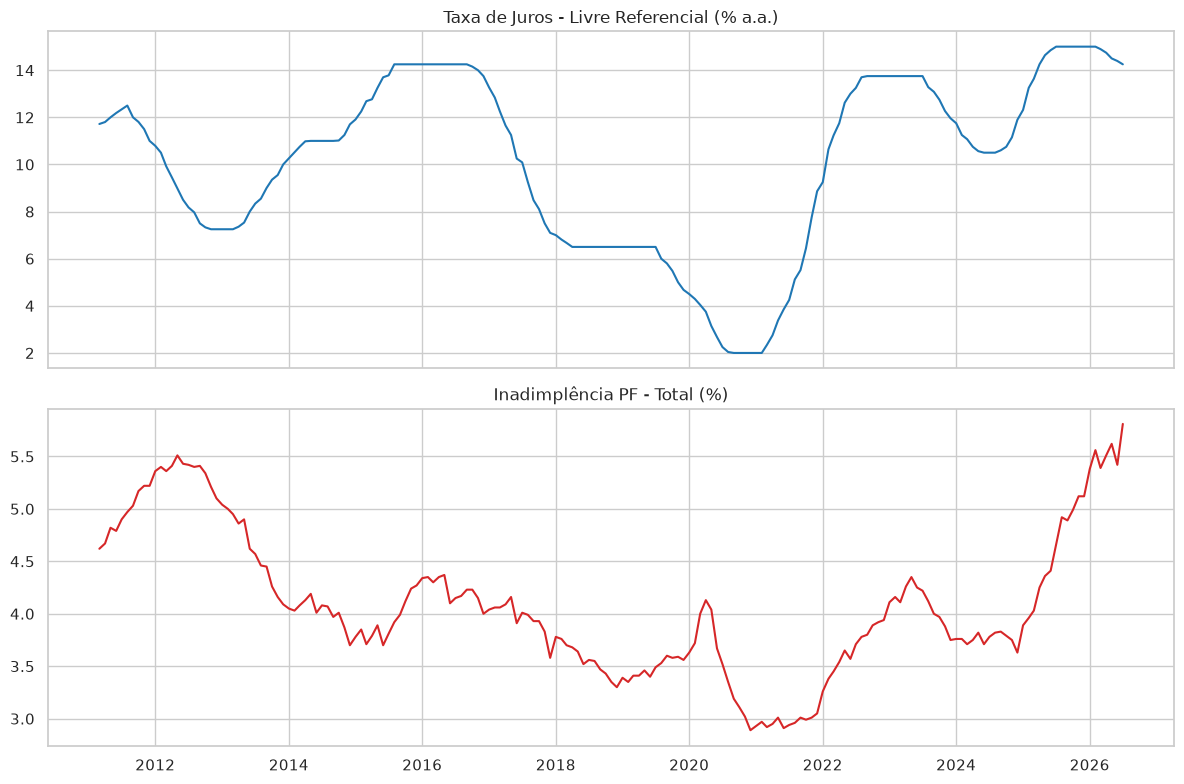

In [4]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 8))
axes[0].plot(df_m.index, df_m['taxa_juros'], color='tab:blue')
axes[0].set_title('Taxa de Juros - Livre Referencial (% a.a.)')
axes[1].plot(df_m.index, df_m['inadimplencia_pf'], color='tab:red')
axes[1].set_title('Inadimplência PF - Total (%)')
plt.tight_layout()
plt.show()

Agora resumimos a distribuição de cada variável. `count` conta meses, `mean` e `std` mostram média e dispersão, e os quartis ajudam a entender valores típicos sem depender apenas de extremos. Como os dados são séries temporais, esses números resumem toda a janela e escondem a ordem dos acontecimentos — por isso complementam, mas não substituem, o gráfico.

In [5]:
df_m.describe()

,taxa_juros,inadimplencia_pf
count,185.000000,185.000000
mean,10.078879,4.089784
std,3.731008,0.685501
min,2.000000,2.890000
25%,7.096774,3.650000
50%,11.000000,4.000000
75%,13.700000,4.360000
max,15.000000,5.810000


Comparamos a correlação nos níveis e nas primeiras diferenças. A correlação em nível pode parecer forte só porque as duas séries têm tendência ao longo do tempo; a correlação das diferenças olha para mudanças de um mês para o seguinte. Mesmo uma correlação alta continua sendo associação, não um teste de causa e efeito.

In [6]:
print('Correlação (níveis):')
print(df_m.corr())
print()
print('Correlação (primeira diferença):')
print(df_m.diff().dropna().corr())

Correlação (níveis):
                  taxa_juros  inadimplencia_pf
taxa_juros           1.00000           0.47423
inadimplencia_pf     0.47423           1.00000

Correlação (primeira diferença):
                  taxa_juros  inadimplencia_pf
taxa_juros          1.000000          0.150654
inadimplencia_pf    0.150654          1.000000


#### **3. As séries têm propriedades adequadas para os testes?**

Em séries temporais, uma tendência persistente pode fazer relações parecerem mais fortes do que realmente são. Chamamos uma série de estacionária quando suas propriedades estatísticas, como média e variância, não mudam de forma sistemática ao longo do tempo.

Usaremos dois testes que partem de hipóteses nulas opostas: no ADF, a hipótese inicial é de raiz unitária (não estacionariedade); no KPSS, a hipótese inicial é de estacionariedade. Olhar os dois em conjunto é mais informativo do que confiar em um único resultado.

A função aplica ADF e KPSS a cada série primeiro em nível e depois à variação mensal (primeira diferença). O p-valor é comparado ao limiar de 5%: abaixo dele, rejeitamos a hipótese nula daquele teste. Se ADF e KPSS apontarem em direções diferentes — ou ficarem perto do limite — tratamos a evidência como inconclusiva, em vez de forçar um rótulo.

In [7]:
def testar_estacionariedade(serie, nome):
    adf_stat, adf_p, *_ = adfuller(serie.dropna(), autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(serie.dropna(), regression='c', nlags='auto')
    print(f'--- {nome} ---')
    print(f'ADF:  estatística={adf_stat:.4f}  p-valor={adf_p:.4f}  ->', 'ESTACIONÁRIA' if adf_p < 0.05 else 'NÃO estacionária')
    print(f'KPSS: estatística={kpss_stat:.4f}  p-valor={kpss_p:.4f}  ->', 'NÃO estacionária' if kpss_p < 0.05 else 'ESTACIONÁRIA')
    print()

for col in df_m.columns:
    testar_estacionariedade(df_m[col], f'{col} (nível)')

df_diff = df_m.diff().dropna()
for col in df_diff.columns:
    testar_estacionariedade(df_diff[col], f'{col} (1ª diferença)')

--- taxa_juros (nível) ---
ADF:  estatística=-1.5999  p-valor=0.4836  -> NÃO estacionária
KPSS: estatística=0.2372  p-valor=0.1000  -> ESTACIONÁRIA

--- inadimplencia_pf (nível) ---
ADF:  estatística=-1.8253  p-valor=0.3680  -> NÃO estacionária
KPSS: estatística=0.5184  p-valor=0.0375  -> NÃO estacionária

--- taxa_juros (1ª diferença) ---
ADF:  estatística=-4.4065  p-valor=0.0003  -> ESTACIONÁRIA
KPSS: estatística=0.1341  p-valor=0.1000  -> ESTACIONÁRIA

--- inadimplencia_pf (1ª diferença) ---
ADF:  estatística=-2.7053  p-valor=0.0731  -> NÃO estacionária
KPSS: estatística=0.4015  p-valor=0.0765  -> ESTACIONÁRIA



/tmp/ipykernel_92719/4006968877.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(serie.dropna(), autolag='AIC')
/tmp/ipykernel_92719/4006968877.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_stat, kpss_p, *_ = kpss(serie.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_92719/4006968877.py:3: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the defau

#### **4. Existe uma relação de longo prazo entre as séries?**

O teste de Johansen procura uma combinação das séries que permaneça estável mesmo quando cada série, isoladamente, tem tendência. Essa relação é chamada de cointegração e, quando as condições do teste são atendidas, aponta para um possível equilíbrio de longo prazo.

Há uma condição importante: a interpretação usual pressupõe que as séries sejam integradas da mesma ordem (por exemplo, ambas I(1)). Como os testes de estacionariedade podem ser inconclusivos — especialmente para a inadimplência — este resultado deve ser lido com cautela, não como confirmação automática de equilíbrio.

Aqui comparamos a estatística do traço com os valores críticos de 90%, 95% e 99%. Em cada linha, a hipótese nula limita quantos vetores de cointegração existem. Se a estatística ultrapassa o valor crítico escolhido, rejeitamos aquela hipótese nula. O número de defasagens e os termos determinísticos também importam; nesta versão usamos as escolhas fixadas no código.

In [8]:
resultado_johansen = coint_johansen(df_m[['taxa_juros', 'inadimplencia_pf']], det_order=0, k_ar_diff=1)

print('Estatística do traço vs. valores críticos (90%, 95%, 99%):')
for i, (stat, crit) in enumerate(zip(resultado_johansen.lr1, resultado_johansen.cvt)):
    print(f'  r <= {i}: estatística={stat:.4f}  críticos={crit}')

Estatística do traço vs. valores críticos (90%, 95%, 99%):
  r <= 0: estatística=17.6932  críticos=[13.4294 15.4943 19.9349]
  r <= 1: estatística=3.3908  críticos=[2.7055 3.8415 6.6349]


/mnt/vms/PROJETOS_DATA_SCIENCE/teste_copilot_2/.venv/lib/python3.12/site-packages/statsmodels/tsa/vector_ar/vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
/mnt/vms/PROJETOS_DATA_SCIENCE/teste_copilot_2/.venv/lib/python3.12/site-packages/statsmodels/tsa/vector_ar/vecm.py:718: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


#### **5. O passado dos juros ajuda a prever a inadimplência?**

Causalidade de Granger é um nome tradicional para um teste de previsão temporal: ele pergunta se incluir valores passados de uma variável melhora a previsão da outra, além do que o próprio passado dela já explica. Não significa, por si só, que encontramos causalidade econômica estrutural.

Nesta seção usamos as primeiras diferenças e testamos cada direção separadamente. O código mostra um teste para cada número de defasagens, até seis meses; como são várias comparações, convém evitar destacar apenas o menor p-valor sem considerar o conjunto dos testes.

Primeiro avaliamos juros → inadimplência. Em `grangercausalitytests`, a primeira coluna é a variável cuja previsão queremos explicar e a segunda é a variável candidata a ajudar nessa previsão. A função auxiliar resume o p-valor do teste F por defasagem. Um p-valor abaixo de 0,05 é evidência contra a hipótese nula daquela defasagem, mas não mede o tamanho nem o sinal do efeito.

In [9]:
def resumir_granger(resultado, max_lag):
    """Imprime o p-valor do teste F por defasagem (grangercausalitytests não tem mais `verbose`)."""
    for lag in range(1, max_lag + 1):
        p_valor = resultado[lag][0]['ssr_ftest'][1]
        print(f'  lag={lag}: p-valor (ssr_ftest) = {p_valor:.4f}', '-> rejeita H0 (causa)' if p_valor < 0.05 else '')

max_lag = 6

print('H0: taxa_juros NÃO causa (Granger) inadimplencia_pf')
resultado_1 = grangercausalitytests(df_diff[['inadimplencia_pf', 'taxa_juros']], maxlag=max_lag)
resumir_granger(resultado_1, max_lag)

H0: taxa_juros NÃO causa (Granger) inadimplencia_pf
  lag=1: p-valor (ssr_ftest) = 0.0311 -> rejeita H0 (causa)
  lag=2: p-valor (ssr_ftest) = 0.0083 -> rejeita H0 (causa)
  lag=3: p-valor (ssr_ftest) = 0.0255 -> rejeita H0 (causa)
  lag=4: p-valor (ssr_ftest) = 0.0436 -> rejeita H0 (causa)
  lag=5: p-valor (ssr_ftest) = 0.0934 
  lag=6: p-valor (ssr_ftest) = 0.0280 -> rejeita H0 (causa)


Agora invertemos a pergunta: inadimplência → juros. Essa verificação de mão dupla ajuda a distinguir uma relação preditiva direcional de uma situação em que ambas as séries parecem antecipar uma à outra. A ausência de significância também não prova que o efeito seja exatamente zero.

In [10]:
print('H0: inadimplencia_pf NÃO causa (Granger) taxa_juros')
resultado_2 = grangercausalitytests(df_diff[['taxa_juros', 'inadimplencia_pf']], maxlag=max_lag)
resumir_granger(resultado_2, max_lag)

H0: inadimplencia_pf NÃO causa (Granger) taxa_juros
  lag=1: p-valor (ssr_ftest) = 0.6603 
  lag=2: p-valor (ssr_ftest) = 0.0089 -> rejeita H0 (causa)
  lag=3: p-valor (ssr_ftest) = 0.0007 -> rejeita H0 (causa)
  lag=4: p-valor (ssr_ftest) = 0.0609 
  lag=5: p-valor (ssr_ftest) = 0.2023 
  lag=6: p-valor (ssr_ftest) = 0.3440 


#### **6. Como as mudanças se relacionam ao longo de vários meses?**

Um VAR acompanha várias séries juntas, permitindo que cada uma dependa de seu próprio passado e do passado das demais. Quando as séries são cointegradas e I(1), um VECM pode representar tanto os ajustes de curto prazo quanto a relação de longo prazo.

As células seguintes mostram as duas ideias, mas a configuração atual estima o VAR nas primeiras diferenças. A resposta ao impulso desse VAR é exploratória; não é automaticamente uma estimativa causal nem substitui um VECM validado. Antes de interpretar esse modelo como principal, confira a ordem de integração e o resultado de Johansen.

Antes de estimar o VAR, comparamos o número de defasagens usando AIC, BIC, HQIC e FPE. Esses critérios equilibram ajuste e complexidade: acrescentar defasagens pode capturar dinâmica, mas usa mais parâmetros. O código testa até oito meses; a tabela ajuda a escolher, não substitui a análise de resíduos nem garante que uma única ordem seja correta.

In [11]:
# --- Opção A: VAR nas séries diferenciadas (usar se NÃO houver cointegração) ---
modelo_var = VAR(df_diff)
selecao_ordem = modelo_var.select_order(maxlags=8)
print(selecao_ordem.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -6.375      -6.339    0.001704      -6.360
1      -7.338      -7.230   0.0006502      -7.294
2      -7.602      -7.421   0.0004997      -7.529
3      -7.797     -7.545*   0.0004108      -7.695
4      -7.836      -7.512   0.0003952      -7.705
5      -7.846      -7.450   0.0003914      -7.685
6      -7.997      -7.528   0.0003368     -7.807*
7     -8.001*      -7.461  0.0003354*      -7.782
8      -7.999      -7.387   0.0003362      -7.751
-------------------------------------------------


/mnt/vms/PROJETOS_DATA_SCIENCE/teste_copilot_2/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Nesta célula usamos a ordem indicada pelo AIC e estimamos o VAR. O resumo mostra coeficientes, erros-padrão e p-valores para cada equação. Um coeficiente individual não deve ser lido isoladamente como efeito causal; o interesse aqui é entender a dinâmica conjunta e, depois, explorar a resposta ao impulso.

In [12]:
lag_escolhido = selecao_ordem.aic
resultado_var = modelo_var.fit(lag_escolhido if lag_escolhido and lag_escolhido > 0 else 1)
print(resultado_var.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 23, Sep, 2026
Time:                     22:18:54
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -7.47500
Nobs:                     177.000    HQIC:                  -7.79500
Log likelihood:           236.875    FPE:                0.000331291
AIC:                     -8.01333    Det(Omega_mle):     0.000281549
--------------------------------------------------------------------
Results for equation taxa_juros
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                       0.005049         0.013665            0.370           0.712
L1.taxa_juros               0.324492         0.078783            4.119           0.000
L1.inadimplencia_pf        -0.2

A resposta ao impulso acompanha como o modelo projeta as variáveis depois de um choque. Aqui calculamos até 12 meses e mostramos respostas ortogonalizadas. Essa ortogonalização depende da ordem das variáveis no modelo (juros aparece antes da inadimplência), então a figura deve ser tratada como uma análise de cenário do VAR, não como prova de que uma mudança exógena na taxa causou o movimento observado.

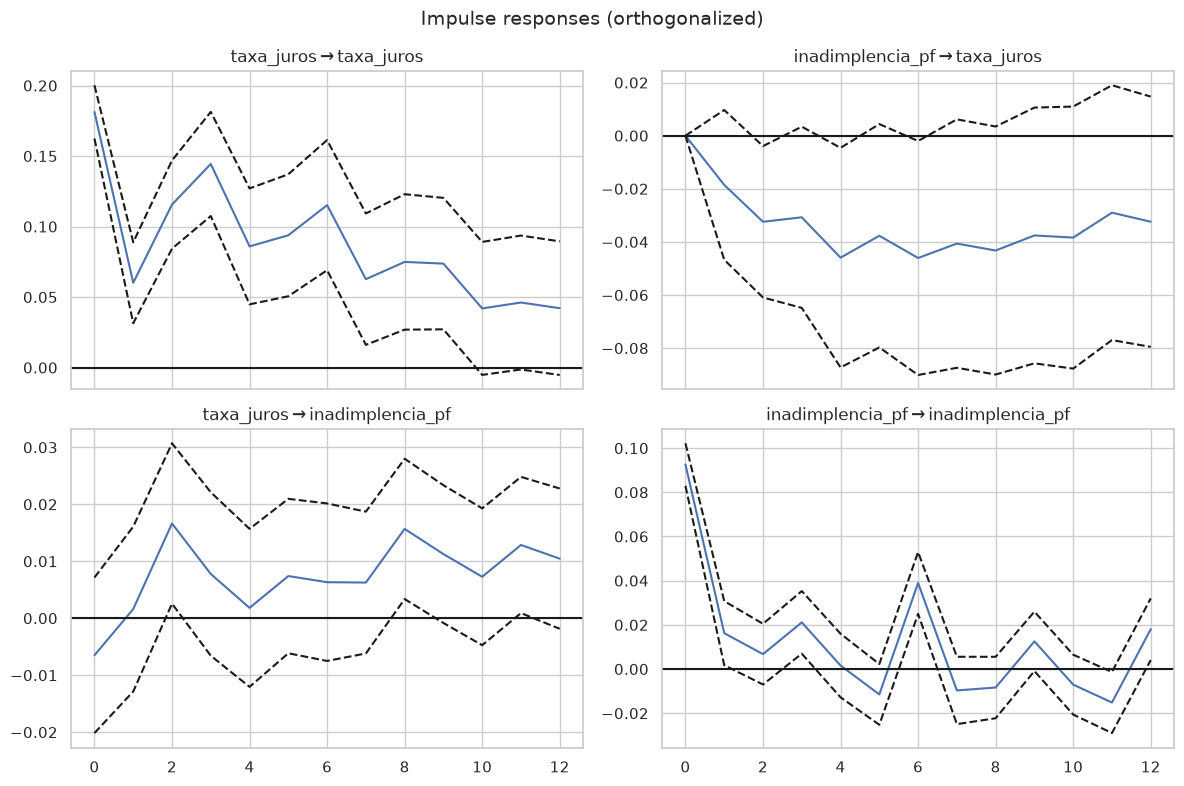

In [13]:
# Função de resposta ao impulso: efeito de um choque na taxa de juros sobre a inadimplência
irf = resultado_var.irf(12)
irf.plot(orth=True, figsize=(12, 8))
plt.tight_layout()
plt.show()

Esta célula deixa uma especificação VECM como referência, mas o código está comentado e portanto não estima nem valida esse modelo durante a execução. Se a cointegração for apropriada, será preciso confirmar a ordem de integração, escolher o posto de cointegração e a defasagem com critérios adequados antes de ativá-lo.

In [14]:
# --- Opção B: VECM nos níveis (usar SE houver cointegração no teste de Johansen) ---
# Descomente e ajuste `coint_rank` conforme o resultado da seção 4.

# modelo_vecm = VECM(df_m[['taxa_juros', 'inadimplencia_pf']], k_ar_diff=lag_escolhido or 1, coint_rank=1, deterministic='ci')
# resultado_vecm = modelo_vecm.fit()
# print(resultado_vecm.summary())

#### **7. Um segundo teste de previsão: Toda–Yamamoto**

O Toda–Yamamoto é outra forma de perguntar se o passado de uma série acrescenta informação para prever a outra. Ele estima as variáveis em nível num VAR com `k + dmax` defasagens: `k` vem da seleção por AIC e `dmax` é a maior ordem de integração considerada. O teste de Wald olha apenas para as primeiras `k` defasagens; as extras ajudam a acomodar a não estacionariedade.

A próxima célula identifica `dmax` com ADF, escolhe `k` em nível e testa as duas direções. Como ADF pode ter dificuldade para distinguir I(1) de I(2), especialmente com mudanças de regime, essa escolha também é uma hipótese de trabalho que merece análise de sensibilidade. Mesmo com esse cuidado, o teste trata de precedência preditiva condicional, não de causalidade estrutural.

In [15]:
def ordem_integracao_adf(serie, max_ordem=2):
    serie = serie.dropna()
    for ordem in range(max_ordem + 1):
        maxlag = min(12, max(0, len(serie) // 4 - 1))
        p_valor = adfuller(serie, maxlag=maxlag, autolag='AIC')[1]
        print(f'  diferença {ordem}: p-valor ADF={p_valor:.4f}')
        if p_valor < 0.05:
            return ordem
        serie = serie.diff().dropna()
    raise ValueError('ADF não rejeitou raiz unitária até I(2); revise especificação e dados.')

ordens_integracao = {
    coluna: ordem_integracao_adf(df_m[coluna])
    for coluna in ['taxa_juros', 'inadimplencia_pf']
}
dmax = max(ordens_integracao.values())
print('Ordens de integração pelo ADF:', ordens_integracao)
print('dmax usado no VAR aumentado:', dmax)

max_lags = min(12, max(1, len(df_m) // 5))
selecao_ty = VAR(df_m[['taxa_juros', 'inadimplencia_pf']]).select_order(maxlags=max_lags)
k = max(1, int(selecao_ty.selected_orders['aic'] or 1))
print(f'Número de defasagens k selecionado pelo AIC: {k}')

ty_juros_para_inadimplencia = toda_yamamoto_causality(
    df_m, cause='taxa_juros', effect='inadimplencia_pf',
    selected_lags=k, max_integration_order=dmax,
)
ty_inadimplencia_para_juros = toda_yamamoto_causality(
    df_m, cause='inadimplencia_pf', effect='taxa_juros',
    selected_lags=k, max_integration_order=dmax,
)

for resultado in [ty_juros_para_inadimplencia, ty_inadimplencia_para_juros]:
    print(
        f"H0: {resultado.cause} não causa (Toda–Yamamoto) {resultado.effect} | "
        f"VAR({resultado.estimated_lags}), Wald={resultado.wald_statistic:.3f}, "
        f"gl={resultado.degrees_of_freedom}, p-valor={resultado.p_value:.4f}"
    )

  diferença 0: p-valor ADF=0.4836
  diferença 1: p-valor ADF=0.0003
  diferença 0: p-valor ADF=0.1204
  diferença 1: p-valor ADF=0.0731
  diferença 2: p-valor ADF=0.0000
Ordens de integração pelo ADF: {'taxa_juros': 1, 'inadimplencia_pf': 2}
dmax usado no VAR aumentado: 2
Número de defasagens k selecionado pelo AIC: 7
H0: taxa_juros não causa (Toda–Yamamoto) inadimplencia_pf | VAR(9), Wald=8.098, gl=7, p-valor=0.3240
H0: inadimplencia_pf não causa (Toda–Yamamoto) taxa_juros | VAR(9), Wald=4.800, gl=7, p-valor=0.6844


/tmp/ipykernel_92719/3170355521.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  p_valor = adfuller(serie, maxlag=maxlag, autolag='AIC')[1]
/tmp/ipykernel_92719/3170355521.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  p_valor = adfuller(serie, maxlag=maxlag, autolag='AIC')[1]
/tmp/ipykernel_92719/3170355521.py:5: FutureWarning: adfuller currently returns a plain 

#### **8. O que aprendemos — e o que ainda não sabemos**

Na execução atual (mar/2011–jul/2026), a amostra tem 185 meses. O AIC selecionou `k=7` e o ADF indicou `dmax=2`, então o teste usou um VAR aumentado com nove defasagens. Os p-valores do Toda–Yamamoto foram 0,324 para juros → inadimplência e 0,684 no sentido inverso. Como ambos são maiores que 0,05, não rejeitamos as hipóteses nulas: **com essa especificação, não encontramos evidência de que uma série ajude a prever a outra**.

Isso não demonstra que os juros não tenham efeito; apenas diz que este teste, com estas variáveis, período e escolhas de modelo, não conseguiu mostrar precedência preditiva estatisticamente clara. Também não prova que os juros causem inadimplência: outras condições econômicas podem atuar ao mesmo tempo.

A ressalva principal é a ordem de integração da inadimplência: o ADF na primeira diferença ficou perto do limiar de 5% (p=0,073), e os testes ADF/KPSS não contam exatamente a mesma história. Para fortalecer o estudo, o próximo passo é testar especificações alternativas, considerar quebras estruturais e incluir controles como inflação, atividade e endividamento das famílias — sempre documentando as escolhas, em vez de procurar uma especificação que apenas produza significância.

#### **Próximas perguntas**

A análise fica mais convincente quando mostramos também o caminho: de onde vieram os dados, quais decisões tomamos, quais evidências apareceram e onde estão as limitações. Uma extensão natural é acrescentar controles macroeconômicos e verificar se a conclusão se mantém.